В цьому домашньому завданні кожне завдання оцінюється по 10 балів.

 **Завдання 1.** Після перегляду лекцій про поняття функії, вступ до лінійної алгебри і мат. формулювання лін. регресії знайдіть найкращу лінію для прогнозу `charges` за `age` **для некурців** (датафрейм `non_smoker_df`) з допомогою

1. Методу МНК (з використанням тільки `numpy`, без `scikit learn`)

2. Full-Batch градієнтного спуску з `numpy` . Протестуйте 3 різних learning rate і зробіть висновок, який є найкращим виходячи з практик для цього, наведених в лекції. Зверніть увагу, що на вхід треба набір даних дворозміний, для цього можливо треба буде трансформувати Ваші дані X в формат, як був в лекції "Математичне формулювання лінійної регресії". Також, градієнтний спуск в нашому випадку може розходитись з навчальним рейтом 0.1, бо цей рейт в цій задачі завеликий. Спробуйте нижчі рейти.
3. З `scikit-learn.LinearRegression`. Тут зверніть увагу, що вхід `X` має бути двовимірним масивом, тому нам потрібно передати dataframe, а не окрему колонку. Якщо у Вас X - колонка (а у Вас так мало б бути), то можна скористатись `X.to_frame()` щоб конвертувати колонку в датафрейм.

Для кожного методу
- знайдіть і виведіть коефіцієнти моделі
- обчисліть прогнози моделі і збережіть в окрему змінну
- порахуйте точність прогнозу RMSE  

Для градієнтного спуску виведіть графік помилки в залежності від ітерації.

А також побудуйте на одному графіку дані `age` проти `charges` в вигляді діаграми розсіювання і всі три лінії регресії, знайдені кожним з методів (для град. спуску оберіть варіант з тим learning rate, який виявився найкращим).

Зробіть висновки, чи відрізняються результати моделей?
Чи є знайдены параметри моделы близькими до ваших найкращих припущень?

In [6]:
import pandas as pd
medical_df = pd.read_csv('/Users/celine/Data Loves/medical-charges.csv') 
non_smoker_df = medical_df[medical_df.smoker == 'no']

medical_df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [7]:
non_smoker_df.head()

,age,sex,bmi,children,smoker,region,charges
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160


1. Методу МНК (з використанням тільки numpy, без scikit learn)

In [8]:
import numpy as np
import matplotlib.pyplot as plt

X = non_smoker_df[['age']].values
y = non_smoker_df['charges'].values

X_with_intercept = np.c_[np.ones((X.shape[0], 1)), X]

X.shape, X_with_intercept.shape, y.shape

((1064, 1), (1064, 2), (1064,))

In [9]:
theta = np.dot(
    np.dot(
        np.linalg.inv(np.dot(X_with_intercept.T, X_with_intercept)),
        X_with_intercept.T
    ),
    y
)

theta

array([-2091.42055657,   267.24891283])

In [10]:
b = theta[0]
w = theta[1]

b, w

(np.float64(-2091.4205565650796), np.float64(267.24891283119973))

In [11]:
y_pred_mnk = X_with_intercept @ theta

y_pred_mnk[:10]

array([ 2719.0598744 ,  5391.54900271,  6727.79356686,  6460.54465403,
        6193.2957412 , 10202.02943367,  7796.78921819,  7796.78921819,
       13943.51421331,  4589.80226421])

In [12]:
rmse_mnk = np.sqrt(np.mean((y - y_pred_mnk) ** 2))

rmse_mnk

np.float64(4662.505766636395)

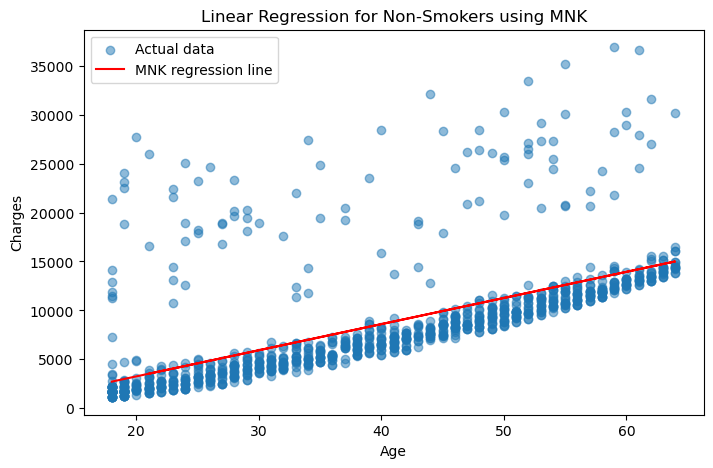

In [14]:
plt.figure(figsize=(8, 5))

plt.scatter(X, y, alpha=0.5, label='Actual data')
plt.plot(X, y_pred_mnk, color='red', label='MNK regression line')

plt.xlabel('Age')
plt.ylabel('Charges')
plt.title('Linear Regression for Non-Smokers using MNK')
plt.legend()
plt.show()

RMSE для моделі МНК становить приблизно 4662.51. В середньому прогноз моделі відрізняється від реальних медичних витрат приблизно на $4662

2. Full-Batch градієнтного спуску з numpy

In [15]:
theta_gd = np.zeros(2)

learning_rate = 0.0001
n_iterations = 100000
m = len(y)

for i in range(n_iterations):
    y_pred_gd = X_with_intercept @ theta_gd
    gradients = (2 / m) * X_with_intercept.T @ (y_pred_gd - y)
    theta_gd = theta_gd - learning_rate * gradients

theta_gd

array([-1873.6113408,   262.3448105])

In [16]:
b_gd = theta_gd[0]
w_gd = theta_gd[1]

b_gd, w_gd

(np.float64(-1873.6113407966322), np.float64(262.34481049895373))

In [17]:
y_pred_gd = X_with_intercept @ theta_gd

rmse_gd = np.sqrt(np.mean((y - y_pred_gd) ** 2))

rmse_gd

np.float64(4663.082007655704)

In [20]:
def gradient_descent(X_with_intercept, y, learning_rate, n_iterations=100000):
    theta = np.zeros(2)
    m = len(y)
    
    for i in range(n_iterations):
        y_pred = X_with_intercept @ theta
        gradients = (2 / m) * X_with_intercept.T @ (y_pred - y)
        theta = theta - learning_rate * gradients
        
        if np.any(np.isnan(theta)) or np.any(np.isinf(theta)):
            return theta, np.nan
    
    y_pred = X_with_intercept @ theta
    rmse = np.sqrt(np.mean((y - y_pred) ** 2))
    
    return theta, rmse

In [21]:
learning_rates = [0.1, 0.001, 0.0001]

results = []

for lr in learning_rates:
    theta_lr, rmse_lr = gradient_descent(X_with_intercept, y, lr)
    
    results.append({
        'learning_rate': lr,
        'b': theta_lr[0],
        'w': theta_lr[1],
        'rmse': rmse_lr
    })

results_df = pd.DataFrame(results)
results_df

/var/folders/w5/zxmrtfk91w1bzjpplmsfvrbr0000gp/T/ipykernel_79658/2347532639.py:7: RuntimeWarning: overflow encountered in matmul
  gradients = (2 / m) * X_with_intercept.T @ (y_pred - y)


,learning_rate,b,w,rmse
0,0.1000,-6.941419e+305,-inf,NaN
1,0.0010,3.915870e+303,inf,NaN
2,0.0001,-1.873611e+03,262.34481,4663.082008


In [22]:
theta_gd_history = np.zeros(2)

learning_rate = 0.0001
n_iterations = 100000
m = len(y)

errors_gd = []

for i in range(n_iterations):
    y_pred_iteration = X_with_intercept @ theta_gd_history
    
    rmse_iteration = np.sqrt(np.mean((y - y_pred_iteration) ** 2))
    errors_gd.append(rmse_iteration)
    
    gradients = (2 / m) * X_with_intercept.T @ (y_pred_iteration - y)
    theta_gd_history = theta_gd_history - learning_rate * gradients

theta_gd_history

array([-1873.6113408,   262.3448105])

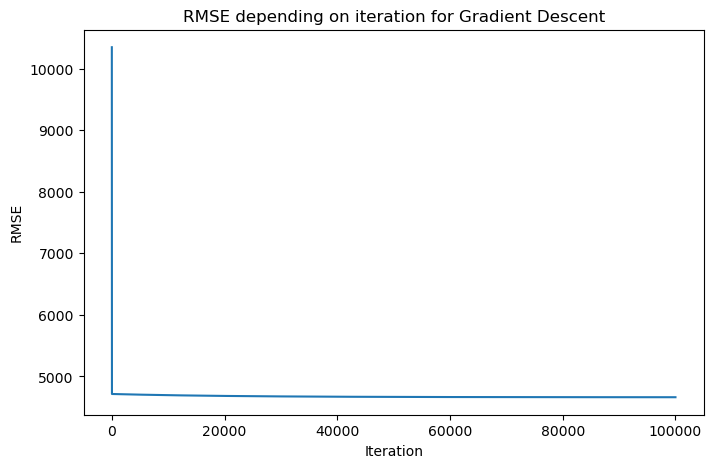

In [26]:
plt.figure(figsize=(8, 5))

plt.plot(errors_gd)

plt.xlabel('Iteration')
plt.ylabel('RMSE')
plt.title('RMSE depending on iteration for Gradient Descent')
plt.show()

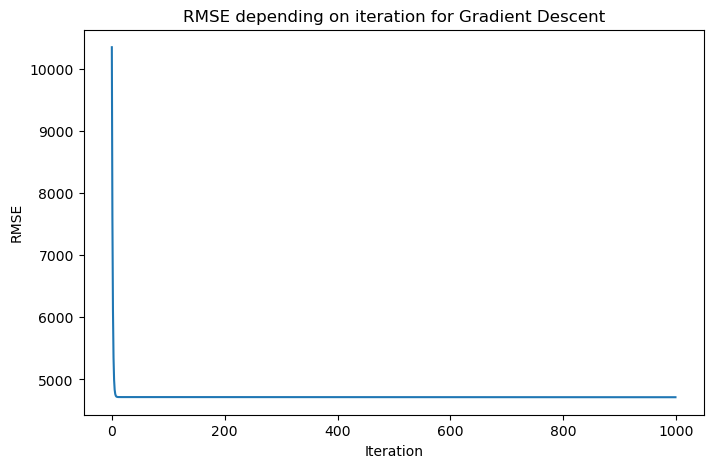

In [27]:
plt.figure(figsize=(8, 5))

plt.plot(errors_gd[:1000])

plt.xlabel('Iteration')
plt.ylabel('RMSE')
plt.title('RMSE depending on iteration for Gradient Descent')
plt.show()

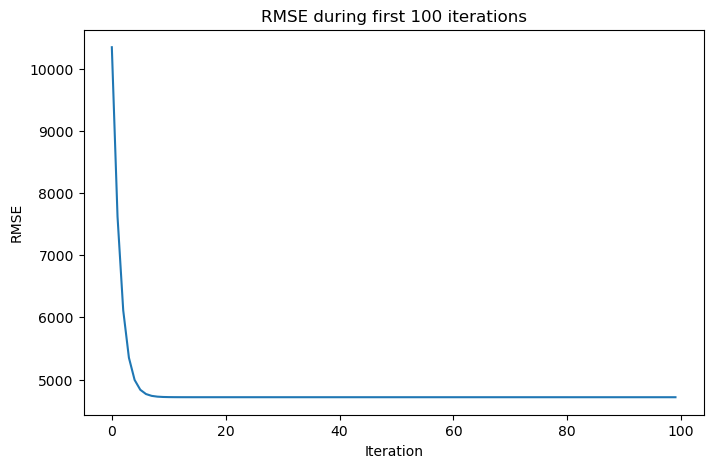

In [28]:
plt.figure(figsize=(8, 5))

plt.plot(errors_gd[:100])

plt.xlabel('Iteration')
plt.ylabel('RMSE')
plt.title('RMSE during first 100 iterations')
plt.show()

learning_rate = 0.1    -- модель розходиться

learning_rate = 0.001  -- модель розходиться

learning_rate = 0.0001 -- RMSE = 4663.08

Було протестовано три значення learning rate: 0.1, 0.001 та 0.0001. При learning rate 0.1 та 0.001 градієнтний спуск розходиться: коефіцієнти стають дуже великими або нескінченними, а RMSE не може бути коректно порахований. При learning rate 0.0001 модель сходиться, а RMSE становить приблизно 4663.08. Це значення дуже близьке до результату МНК, тому серед протестованих варіантів найкращим є learning rate = 0.0001.


3. З scikit-learn.LinearRegression

In [29]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

X_sklearn = non_smoker_df[['age']]
y_sklearn = non_smoker_df['charges']

X_sklearn.shape, y_sklearn.shape

((1064, 1), (1064,))

In [30]:
sklearn_model = LinearRegression()

sklearn_model.fit(X_sklearn, y_sklearn)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [32]:
b_sklearn = sklearn_model.intercept_ #це точка, з якої починається лінія
w_sklearn = sklearn_model.coef_[0] #це нахил лінії

b_sklearn, w_sklearn

(np.float64(-2091.4205565650245), np.float64(267.2489128311981))

In [33]:
y_pred_sklearn = sklearn_model.predict(X_sklearn)

y_pred_sklearn[:10]

array([ 2719.0598744 ,  5391.54900271,  6727.79356686,  6460.54465403,
        6193.2957412 , 10202.02943367,  7796.78921819,  7796.78921819,
       13943.51421331,  4589.80226421])

In [34]:
rmse_sklearn = np.sqrt(mean_squared_error(y_sklearn, y_pred_sklearn))

rmse_sklearn

np.float64(4662.505766636395)

In [35]:
comparison_df = pd.DataFrame({
    'method': ['MNK', 'Gradient Descent', 'Sklearn'],
    'b': [b, b_gd, b_sklearn],
    'w': [w, w_gd, w_sklearn],
    'rmse': [rmse_mnk, rmse_gd, rmse_sklearn]
})

comparison_df

,method,b,w,rmse
0,MNK,-2091.420557,267.248913,4662.505767
1,Gradient Descent,-1873.611341,262.344810,4663.082008
2,Sklearn,-2091.420557,267.248913,4662.505767


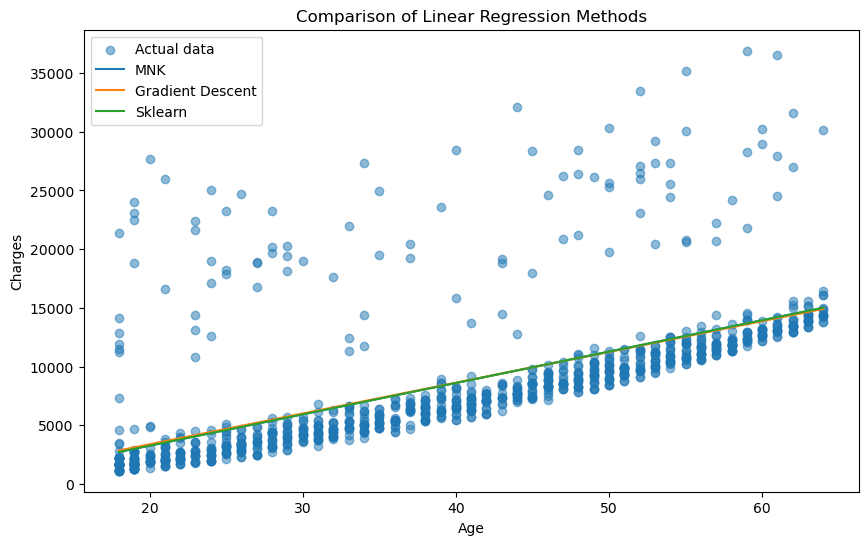

In [36]:
order = np.argsort(X.ravel())

plt.figure(figsize=(10, 6))

plt.scatter(X, y, alpha=0.5, label='Actual data')

plt.plot(X.ravel()[order], y_pred_mnk[order], label='MNK')
plt.plot(X.ravel()[order], y_pred_gd[order], label='Gradient Descent')
plt.plot(X.ravel()[order], y_pred_sklearn[order], label='Sklearn')

plt.xlabel('Age')
plt.ylabel('Charges')
plt.title('Comparison of Linear Regression Methods')
plt.legend()
plt.show()

Метод МНК та модель `sklearn.LinearRegression` дали однакові результати: коефіцієнт `b` становить приблизно -2091.42, коефіцієнт `w` — приблизно 267.25, а RMSE — приблизно 4662.51.

Модель, побудована за допомогою Full-Batch градієнтного спуску, дала дуже близький результат: `b` приблизно -1873.61, `w` приблизно 262.34, а RMSE приблизно 4663.08. Серед протестованих learning rate найкращим виявився `0.0001`, тому що при більших значеннях градієнтний спуск розходився.

Результати моделей майже не відрізняються за якістю прогнозу. МНК та sklearn дали однакові параметри, а градієнтний спуск дуже близько наблизився до них. Знайдені параметри також близькі до попередніх найкращих припущень: коефіцієнт `w` показує, що для некурців медичні витрати в середньому зростають приблизно на 260–267 з кожним роком віку.

 **Завдання 2.** Навчіть модель лінійної регресії з допомогою sklearn оцінювати розмір медичних збори для **курців** за їх віком.
Виведіть
- точність моделі
-  коефіцієнти
-  візуалізуйте модель у вигляді лінії на графіку розсіювання `age` проти `charges`

і зробіть висновки, чи це хороша модель, чи ви б її використовували в компанії?

In [37]:
smoker_df = medical_df[medical_df.smoker == 'yes']

X_smoker = smoker_df[['age']]
y_smoker = smoker_df['charges']

X_smoker.shape, y_smoker.shape

((274, 1), (274,))

In [38]:
smoker_model = LinearRegression()

smoker_model.fit(X_smoker, y_smoker)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [39]:
b_smoker = smoker_model.intercept_
w_smoker = smoker_model.coef_[0]

b_smoker, w_smoker

(np.float64(20294.12812691597), np.float64(305.23760210982874))

b_smoker = 20294.13 (базовий рівень витрат у моделі для курців значно вищий, ніж для некурців)

w_smoker = 305.24 (для курців з кожним додатковим роком віку прогнозовані медичні витрати в середньому зростають приблизно на 305)

charges = 305.24 * age + 20294.13

In [40]:
y_pred_smoker = smoker_model.predict(X_smoker)

y_pred_smoker[:10]

array([26093.642567  , 39218.85945773, 28535.54338388, 29451.25619021,
       30672.20659865, 29756.49379232, 27009.35537333, 28840.78098599,
       30977.44420076, 38608.38425351])

In [41]:
rmse_smoker = np.sqrt(mean_squared_error(y_smoker, y_pred_smoker))

rmse_smoker

np.float64(10711.00334810241)

Це доволі велика помилка

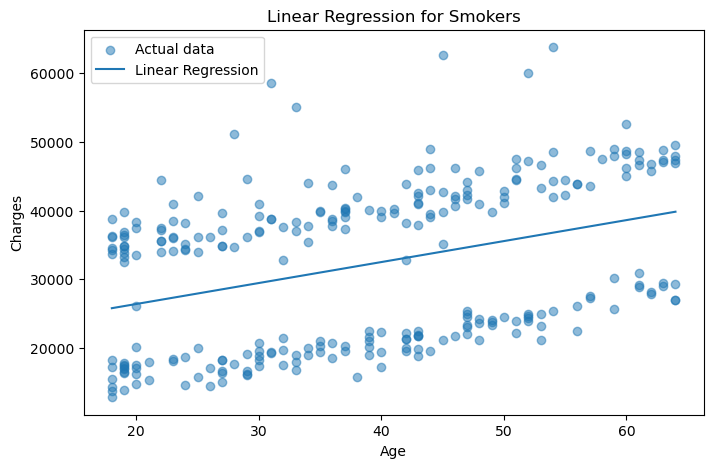

In [42]:
order_smoker = np.argsort(X_smoker['age'].values)

plt.figure(figsize=(8, 5))

plt.scatter(X_smoker, y_smoker, alpha=0.5, label='Actual data')
plt.plot(
    X_smoker['age'].values[order_smoker],
    y_pred_smoker[order_smoker],
    label='Linear Regression'
)

plt.xlabel('Age')
plt.ylabel('Charges')
plt.title('Linear Regression for Smokers')
plt.legend()
plt.show()

Модель показує, що для курців з віком медичні витрати в середньому зростають. Коефіцієнт `w` становить приблизно 305.24, тобто з кожним роком прогнозований `charges` збільшується приблизно на 305. Але точки дуже сильно розкидані навколо лінії.
Видно, що одна пряма не дуже добре описує всі дані.

Але RMSE становить приблизно 10711, тобто помилка моделі досить велика. На графіку також видно, що точки сильно розкидані навколо лінії. Тому я б не сказала, що це дуже хороша модель для реального використання в компанії. Її можна використовувати лише як простий базовий приклад, але для кращого прогнозу треба додати інші ознаки, наприклад BMI, стать, кількість дітей та регіон.
